# notebooks/03_model_building.ipynb

In [22]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

## Load Model-Ready Data

In [23]:
DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

Data Shape: (152963, 26)


rv       bpv      good       bad          rq    vix  \
Date       Stock                                                              
2003-02-03 AAPL   7.025066  6.011066  4.929262  2.095804  191.638996  31.02   
           AMGN   2.423086  2.491991  1.628248  0.794838    7.808419  31.02   
           AMZN   2.666827  2.511467  1.616915  1.049912   10.205894  31.02   
           AXP    3.101161  3.304581  1.450340  1.650822    9.342367  31.02   
           BA     5.870352  6.632632  3.171254  2.699098   50.703639  31.02   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-02-03 AAPL   6.026879  8.196890      7.177777       6.109642  ...   
           AMGN   1.944900  3.797950      3.660728       3.129707  ...   
           AMZN   3.429612  5.460273      4.644653       6.378772  ...   
           AXP    4.478863  4.082929      6.028416       4.349161  ...   
           BA     4.191642  4.506228      6.684536       4.489795  ...   

                  vix_lag_1  rv_vix_interaction  bad_rv_interaction  \
Date       Stock                                                      
2003-02-03 AAPL       31.17          255.497050           20.739023   
           AMGN       31.17          118.382090            6.676749   
           AMZN       31.17          170.196696           15.206346   
           AXP        31.17          127.264895            7.118822   
           BA         31.17          140.459126            8.331612   

                  jump_share  jump_share_rolling_5  downside_share  \
Date       Stock                                                     
2003-02-03 AAPL     0.144340              0.186098        0.298332   
           AMGN     0.000000              0.145744        0.328027   
           AMZN     0.058256              0.082077        0.393693   
           AXP      0.000000              0.023774        0.532324   
           BA       0.000000              0.166030        0.459785   

                  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  vix_zscore_22  
Date       Stock                                                              
2003-02-03 AAPL         3.883139       3.177883      1.476383       1.055303  
           AMGN         1.329919       0.755096      0.813622       1.055303  
           AMZN         1.435031       4.191575      1.205634       1.055303  
           AXP          0.971422       2.706007      1.409176       1.055303  
           BA           1.471332       2.333607      2.772795       1.055303  

[5 rows x 26 columns]

## Define Features (X) and Target (Y)

In [24]:
Y = df['Y_reg']

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())

Target (Y) shape: (152963,)
HAR Features (X_har) shape: (152963, 3)
Advanced Features (X_advanced) shape: (152963, 19)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-02-03 AAPL   8.196890      7.177777       6.109642
           AMGN   3.797950      3.660728       3.129707
           AMZN   5.460273      4.644653       6.378772
           AXP    4.082929      6.028416       4.349161
           BA     4.506228      6.684536       4.489795

## Setup Rolling Window Validation

Initialized TimeSeriesSplit with 2 splits.


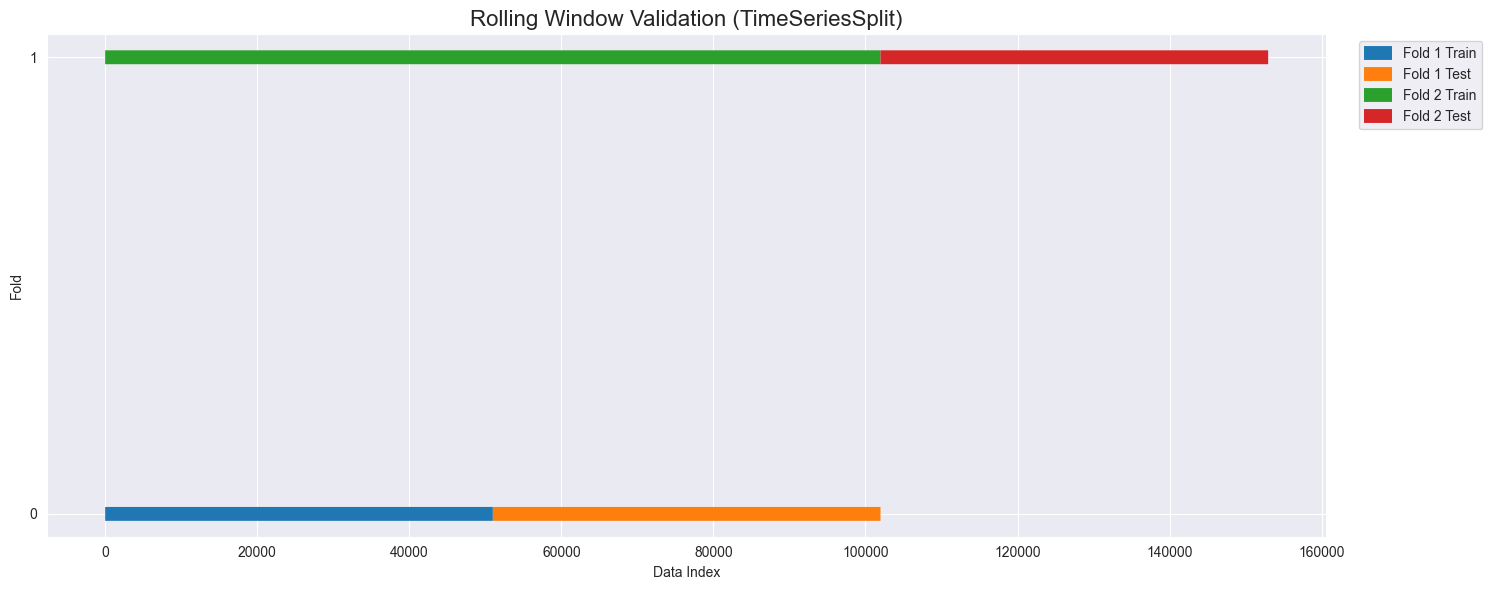

In [25]:
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.set_yticks(range(N_SPLITS))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train & Evaluate HAR Baseline

In [26]:
# ============================================================
# HAR Baseline (Reproducible & Independent of Extra Features)
# ============================================================

print("\nPreparing clean HAR baseline dataset...")

# HAR feature list
har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']

# Construct a clean DataFrame containing ONLY HAR features + target
df_har = df[har_features + ['Y_reg']].dropna().copy()

print("HAR dataset size:", df_har.shape)

# Separate X and Y
X_har = df_har[har_features]
Y = df_har['Y_reg']

# Log-log transform
Y_log = np.log1p(Y)
X_har_log = np.log1p(X_har)

har_mse_scores_log = []
har_models_log = []

print('\nTraining & Evaluation for HAR (Log-Log Specification)...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har_log)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har_log.iloc[train_index], X_har_log.iloc[test_index]
    y_train_log, y_test_log = Y_log.iloc[train_index], Y_log.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model_log = LinearRegression()
    har_model_log.fit(X_train, y_train_log)
    
    y_pred_log = har_model_log.predict(X_test)
    
    # Convert back to original scale
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    y_pred_orig[y_pred_orig < 0] = 0
    
    # Compute MSE
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    
    har_mse_scores_log.append(mse)
    har_models_log.append(har_model_log)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")

# Average MSE
average_har_mse_log = np.mean(har_mse_scores_log)
print(f"\nAverage HAR Model MSE (Log-Log Trained): {average_har_mse_log:.6f}")



Preparing clean HAR baseline dataset...
HAR dataset size: (152963, 4)

Training & Evaluation for HAR (Log-Log Specification)...
--- Fold 1/2 ---
  Train size: 50989, Test size: 50987
  Fold 1 MSE (Original Scale): 4.911041
--- Fold 2/2 ---
  Train size: 101976, Test size: 50987
  Fold 2 MSE (Original Scale): 15.023447

Average HAR Model MSE (Log-Log Trained): 9.967244


In [27]:
import joblib
MODEL_PATH = os.path.join("..", "models")

final_har_model = har_models_log[-1]
har_model_filename = os.path.join(MODEL_PATH, "har_baseline_model.joblib")
joblib.dump(final_har_model, har_model_filename)

print(f"Final HAR model saved to: {har_model_filename}")

Final HAR model saved to: ..\models\har_baseline_model.joblib


## Isolation Forest Part

In [28]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [29]:
MODEL_PATH = os.path.join("..", "models", "har_baseline_model.joblib")

har_model = joblib.load(MODEL_PATH)

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]
Y_reg = df['Y_reg']

## Calculate Model Residuals (Errors)

In [30]:
har_predictions = har_model.predict(X_har)
df['har_error'] = Y_reg - har_predictions
print("HAR model residuals calculated.")
display(df[['Y_reg', 'har_error']].describe())

HAR model residuals calculated.


,Y_reg,har_error
count,152963.000000,152963.000000
mean,2.309663,0.165238
std,5.570723,4.213534
min,0.045685,-128.883107
25%,0.676325,-0.449631
50%,1.180070,-0.105073
75%,2.202751,0.334604
max,400.349507,349.952678


## Standardize Residuals

In [31]:
scaler = StandardScaler()
df['error_scaled'] = df.groupby(level='Stock')['har_error'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

print("Residuals have been standardized per stock.")
display(df[['har_error', 'error_scaled']].head())

Residuals have been standardized per stock.


har_error  error_scaled
Date       Stock                         
2003-02-03 AAPL   -0.400820     -0.161988
           AMGN   -1.266035     -0.460376
           AMZN   -1.620214     -0.485459
           AXP     0.089731     -0.027175
           BA     -0.549307     -0.129510

## Train the Isolation Forest

In [32]:
train_end_date = '2019-12-31'
train_data = df.loc[df.index.get_level_values('Date') <= train_end_date]

X_train_errors = train_data['error_scaled'].values.reshape(-1, 1)
print(f"Training Isolation Forest on {len(X_train_errors)} data points...")

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_errors)

Training Isolation Forest on 120983 data points...


,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


## Create Anomaly Labels (Y_class)

In [33]:
X_all_errors = df['error_scaled'].values.reshape(-1, 1)

anomaly_predictions = iso_forest.predict(X_all_errors)

df['is_abnormal'] = np.where(anomaly_predictions == -1, 1, 0)

abnormal_pct = df['is_abnormal'].mean() * 100
print(f"Total anomalies detected across all data: {df['is_abnormal'].sum()}")
print(f"Percentage of anomalies: {abnormal_pct:.2f}%")

display(df[['har_error', 'error_scaled', 'is_abnormal']].head())

Total anomalies detected across all data: 8162
Percentage of anomalies: 5.34%


har_error  error_scaled  is_abnormal
Date       Stock                                      
2003-02-03 AAPL   -0.400820     -0.161988            0
           AMGN   -1.266035     -0.460376            0
           AMZN   -1.620214     -0.485459            0
           AXP     0.089731     -0.027175            0
           BA     -0.549307     -0.129510            0

## Visualize and Validate the Anomalies

Anomalies found for AAPL: 422


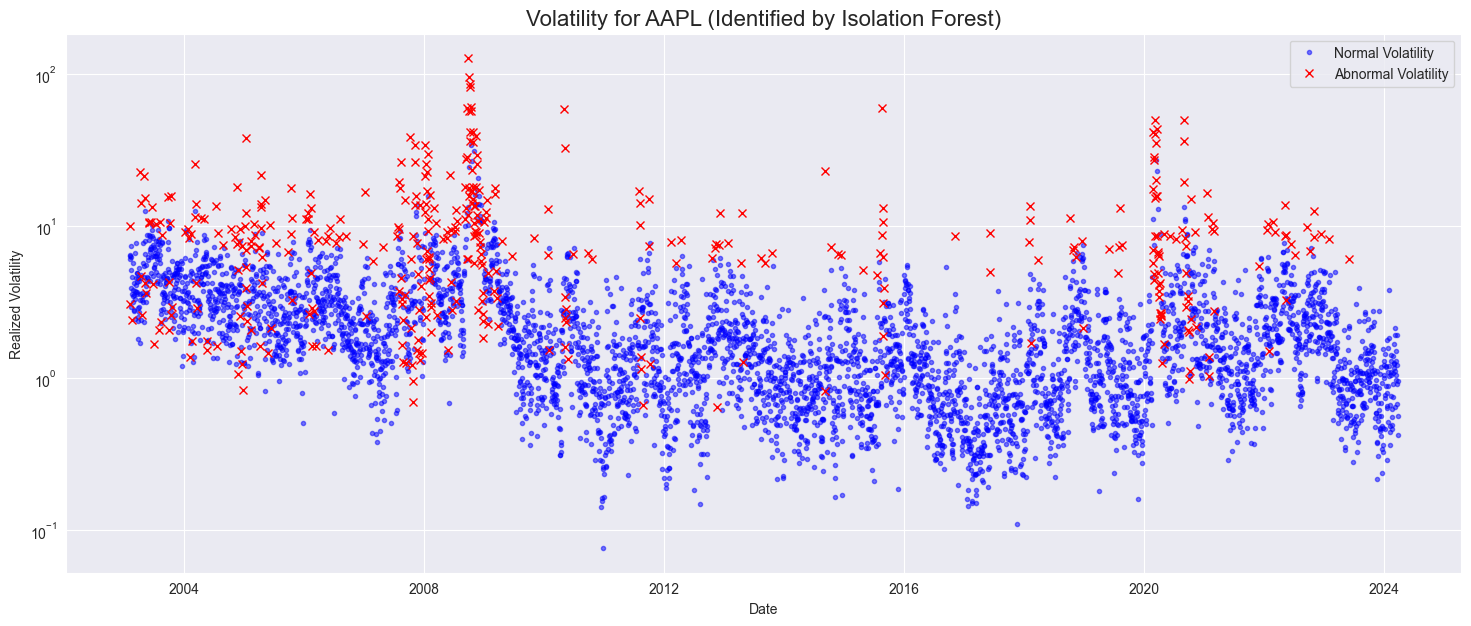

In [34]:
stock_to_plot = 'AAPL'
df_stock = df.loc[pd.IndexSlice[:, stock_to_plot], :]

anomalies = df_stock[df_stock['is_abnormal'] == 1]
normals = df_stock[df_stock['is_abnormal'] == 0]

print(f"Anomalies found for {stock_to_plot}: {len(anomalies)}")

plt.figure(figsize=(18, 7))
plt.plot(
    normals.index.get_level_values('Date'), 
    normals['Y_reg'], 
    linestyle='None', 
    marker='.', 
    color='blue', 
    alpha=0.5, 
    label='Normal Volatility'
)
plt.plot(
    anomalies.index.get_level_values('Date'), 
    anomalies['Y_reg'], 
    linestyle='None', 
    marker='x', 
    color='red', 
    label='Abnormal Volatility'
)

plt.title(f'Volatility for {stock_to_plot} (Identified by Isolation Forest)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.legend()
plt.yscale('log')
plt.show()

In [44]:
df['Y_class'] = df.groupby('Stock')['is_abnormal'].shift(-1)

df['abnormal_share_10'] = (
    df.groupby('Stock')['is_abnormal']
      .rolling(window=10, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

df_model_ready_phase4 = df.dropna()

print(f"Original data size: {df.shape}")
print(f"Final data size for Phase 4: {df_model_ready_phase4.shape}")

output_path = os.path.join("..", "data", "panel_data_phase4_ready.parquet")
df_model_ready_phase4.to_parquet(output_path)
display(df_model_ready_phase4.head())

Original data size: (152933, 31)
Final data size for Phase 4: (152903, 31)


rv       bpv      good       bad          rq    vix  \
Date       Stock                                                              
2003-02-03 AAPL   7.025066  6.011066  4.929262  2.095804  191.638996  31.02   
           AMGN   2.423086  2.491991  1.628248  0.794838    7.808419  31.02   
           AMZN   2.666827  2.511467  1.616915  1.049912   10.205894  31.02   
           AXP    3.101161  3.304581  1.450340  1.650822    9.342367  31.02   
           BA     5.870352  6.632632  3.171254  2.699098   50.703639  31.02   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-02-03 AAPL   6.026879  8.196890      7.177777       6.109642  ...   
           AMGN   1.944900  3.797950      3.660728       3.129707  ...   
           AMZN   3.429612  5.460273      4.644653       6.378772  ...   
           AXP    4.478863  4.082929      6.028416       4.349161  ...   
           BA     4.191642  4.506228      6.684536       4.489795  ...   

                  downside_share  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  \
Date       Stock                                                                
2003-02-03 AAPL         0.298332        3.883139       3.177883      1.476383   
           AMGN         0.328027        1.329919       0.755096      0.813622   
           AMZN         0.393693        1.435031       4.191575      1.205634   
           AXP          0.532324        0.971422       2.706007      1.409176   
           BA           0.459785        1.471332       2.333607      2.772795   

                  vix_zscore_22  har_error  error_scaled  is_abnormal  \
Date       Stock                                                        
2003-02-03 AAPL        1.055303  -0.400820     -0.161988            0   
           AMGN        1.055303  -1.266035     -0.460376            0   
           AMZN        1.055303  -1.620214     -0.485459            0   
           AXP         1.055303   0.089731     -0.027175            0   
           BA          1.055303  -0.549307     -0.129510            0   

                  Y_class  abnormal_share_10  
Date       Stock                              
2003-02-03 AAPL       1.0                0.0  
           AMGN       0.0                0.0  
           AMZN       0.0                0.0  
           AXP        0.0                0.0  
           BA         0.0                0.0  

[5 rows x 31 columns]

## Advanced ML Modeling & Interpretation

In [45]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap

import warnings
warnings.filterwarnings('ignore')

In [46]:
print("Loaded advanced modeling libraries (XGBoost, SHAP).")

PHASE_4_DATA_PATH = os.path.join('..', 'data', 'panel_data_phase4_ready.parquet')
df = pd.read_parquet(PHASE_4_DATA_PATH)

print(f"Loaded Phase 4 data: {df.shape}")
display(df.head())

Loaded advanced modeling libraries (XGBoost, SHAP).
Loaded Phase 4 data: (152903, 31)


rv       bpv      good       bad          rq    vix  \
Date       Stock                                                              
2003-02-03 AAPL   7.025066  6.011066  4.929262  2.095804  191.638996  31.02   
           AMGN   2.423086  2.491991  1.628248  0.794838    7.808419  31.02   
           AMZN   2.666827  2.511467  1.616915  1.049912   10.205894  31.02   
           AXP    3.101161  3.304581  1.450340  1.650822    9.342367  31.02   
           BA     5.870352  6.632632  3.171254  2.699098   50.703639  31.02   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-02-03 AAPL   6.026879  8.196890      7.177777       6.109642  ...   
           AMGN   1.944900  3.797950      3.660728       3.129707  ...   
           AMZN   3.429612  5.460273      4.644653       6.378772  ...   
           AXP    4.478863  4.082929      6.028416       4.349161  ...   
           BA     4.191642  4.506228      6.684536       4.489795  ...   

                  downside_share  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  \
Date       Stock                                                                
2003-02-03 AAPL         0.298332        3.883139       3.177883      1.476383   
           AMGN         0.328027        1.329919       0.755096      0.813622   
           AMZN         0.393693        1.435031       4.191575      1.205634   
           AXP          0.532324        0.971422       2.706007      1.409176   
           BA           0.459785        1.471332       2.333607      2.772795   

                  vix_zscore_22  har_error  error_scaled  is_abnormal  \
Date       Stock                                                        
2003-02-03 AAPL        1.055303  -0.400820     -0.161988            0   
           AMGN        1.055303  -1.266035     -0.460376            0   
           AMZN        1.055303  -1.620214     -0.485459            0   
           AXP         1.055303   0.089731     -0.027175            0   
           BA          1.055303  -0.549307     -0.129510            0   

                  Y_class  abnormal_share_10  
Date       Stock                              
2003-02-03 AAPL       1.0                0.0  
           AMGN       0.0                0.0  
           AMZN       0.0                0.0  
           AXP        0.0                0.0  
           BA         0.0                0.0  

[5 rows x 31 columns]

In [47]:
Y_reg = df['Y_reg']
Y_reg_log = np.log1p(Y_reg)

Y_class = df['Y_class']

non_feature_cols = [
    'rv', 'bpv', 'good', 'bad', 'rq', 'vix',
    'Y_reg',                                 
    'har_error', 'error_scaled', 'is_abnormal',
    'Y_class'                               
]
X_advanced = df.drop(columns=non_feature_cols)
X_advanced_log = np.log1p(X_advanced)

print(f"Advanced Features (X_advanced) shape: {X_advanced.shape}")
print(f"Regression Target (Y_reg) shape: {Y_reg.shape}")
print(f"Classification Target (Y_class) shape: {Y_class.shape}")
display(X_advanced.head())

Advanced Features (X_advanced) shape: (152903, 20)
Regression Target (Y_reg) shape: (152903,)
Classification Target (Y_class) shape: (152903,)


rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                     
2003-02-03 AAPL   8.196890      7.177777       6.109642   5.406336   
           AMGN   3.797950      3.660728       3.129707   2.772656   
           AMZN   5.460273      4.644653       6.378772   5.649125   
           AXP    4.082929      6.028416       4.349161   4.443983   
           BA     4.506228      6.684536       4.489795   4.629536   

                  bpv_rolling_5  good_lag_1  bad_lag_1  bad_lag_5    rq_lag_1  \
Date       Stock                                                                
2003-02-03 AAPL        6.148265    5.666781   2.530109   2.768120  283.782162   
           AMGN        3.044024    2.039962   1.757988   1.713505   24.627068   
           AMZN        4.237505    2.675367   2.784906   1.720937   42.288863   
           AXP         5.774703    2.339371   1.743558   2.118073   15.609303   
           BA          5.091332    2.657318   1.848910   3.242916   31.139052   

                  vix_lag_1  rv_vix_interaction  bad_rv_interaction  \
Date       Stock                                                      
2003-02-03 AAPL       31.17          255.497050           20.739023   
           AMGN       31.17          118.382090            6.676749   
           AMZN       31.17          170.196696           15.206346   
           AXP        31.17          127.264895            7.118822   
           BA         31.17          140.459126            8.331612   

                  jump_share  jump_share_rolling_5  downside_share  \
Date       Stock                                                     
2003-02-03 AAPL     0.144340              0.186098        0.298332   
           AMGN     0.000000              0.145744        0.328027   
           AMZN     0.058256              0.082077        0.393693   
           AXP      0.000000              0.023774        0.532324   
           BA       0.000000              0.166030        0.459785   

                  kurtosis_proxy  vol_of_vol_10  vol_of_vol_5  vix_zscore_22  \
Date       Stock                                                               
2003-02-03 AAPL         3.883139       3.177883      1.476383       1.055303   
           AMGN         1.329919       0.755096      0.813622       1.055303   
           AMZN         1.435031       4.191575      1.205634       1.055303   
           AXP          0.971422       2.706007      1.409176       1.055303   
           BA           1.471332       2.333607      2.772795       1.055303   

                  abnormal_share_10  
Date       Stock                     
2003-02-03 AAPL                 0.0  
           AMGN                 0.0  
           AMZN                 0.0  
           AXP                  0.0  
           BA                   0.0

In [48]:
## --- Setup Validation ---
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

## XGBoost

In [54]:
print("--- Starting Task 4.1: Advanced Regression (XGBoost) ---")

X_train_data = X_advanced 
y_train_data = Y_reg_log

xgb_reg_mse_scores = []
xgb_reg_models = []

for i, (train_index, test_index) in enumerate(tscv.split(X_train_data)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')

    X_train, X_test = X_train_data.iloc[train_index], X_train_data.iloc[test_index]
    y_train_log, y_test_log = y_train_data.iloc[train_index], y_train_data.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    xgb_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.9,
        n_estimators=350,
        learning_rate=0.04,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_reg.fit(X_train, y_train_log)
    
    y_pred_log = xgb_reg.predict(X_test)
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    
    y_pred_orig[y_pred_orig < 0] = 0 
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    xgb_reg_mse_scores.append(mse)
    xgb_reg_models.append(xgb_reg)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")

avg_xgb_mse = np.mean(xgb_reg_mse_scores)

print("\n--- Regression Model Comparison ---")
print(f"  Average HAR Model MSE (Log-Log):     {average_har_mse_log:.6f}")
print(f"  Average XGB Regressor MSE:           {avg_xgb_mse:.6f}")

improvement = (average_har_mse_log - avg_xgb_mse) / average_har_mse_log
print(f"\n  Improvement over HAR: {improvement:.2%}")

--- Starting Task 4.1: Advanced Regression (XGBoost) ---
--- Fold 1/2 ---
  Train size: 50969, Test size: 50967
  Fold 1 MSE (Original Scale): 4.416323
--- Fold 2/2 ---
  Train size: 101936, Test size: 50967
  Fold 2 MSE (Original Scale): 13.136908

--- Regression Model Comparison ---
  Average HAR Model MSE (Log-Log):     9.967244
  Average XGB Regressor MSE:           8.776615

  Improvement over HAR: 11.95%


## Anomaly Classification (XGBoost)


--- Starting Task 4.2: Anomaly Classification (XGBoost + Dual Threshold Display) ---
--- Fold 1/2 ---
  Train size: 50969, Test size: 50967
  Train Abnormal Pct: 8.64%, Test Abnormal Pct: 2.22%
  Calculated scale_pos_weight: 10.58
--- Fold 2/2 ---
  Train size: 101936, Test size: 50967
  Train Abnormal Pct: 5.43%, Test Abnormal Pct: 5.15%
  Calculated scale_pos_weight: 17.43

================ Threshold = 0.50 ================

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.90      0.94     48340
Abnormal (1)       0.27      0.67      0.39      2627

    accuracy                           0.89     50967
   macro avg       0.63      0.79      0.66     50967
weighted avg       0.94      0.89      0.91     50967



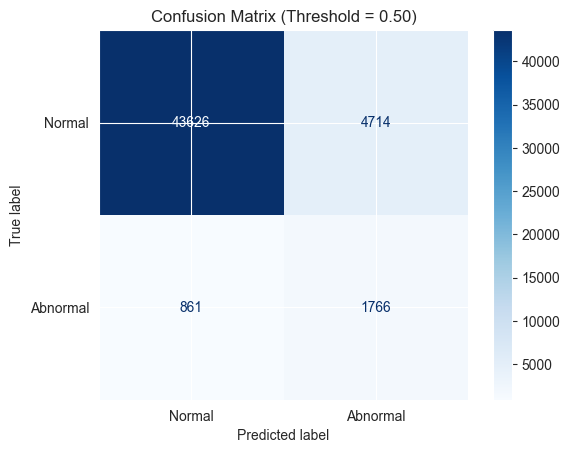


================ Threshold = 0.75 ================

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.97      0.97     48340
Abnormal (1)       0.47      0.55      0.51      2627

    accuracy                           0.94     50967
   macro avg       0.72      0.76      0.74     50967
weighted avg       0.95      0.94      0.95     50967



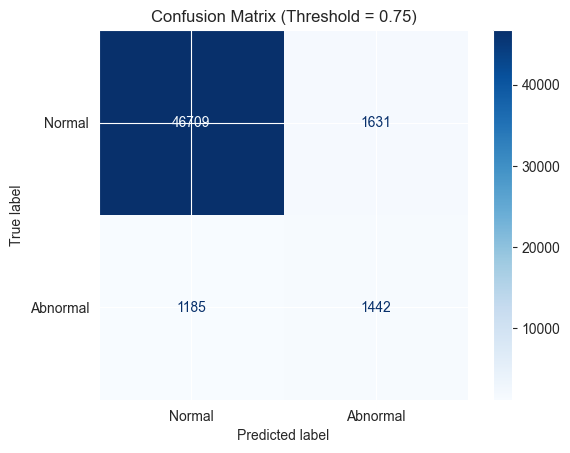

In [76]:
print("\n--- Starting Task 4.2: Anomaly Classification (XGBoost + Dual Threshold Display) ---")

xgb_class_models = []
last_fold_data = {}

FINAL_THRESHOLDS = [0.50, 0.75]

for i, (train_index, test_index) in enumerate(tscv.split(X_advanced)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_advanced.iloc[train_index], X_advanced.iloc[test_index]
    y_train, y_test = Y_class.iloc[train_index], Y_class.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"  Train Abnormal Pct: {y_train.mean():.2%}, Test Abnormal Pct: {y_test.mean():.2%}")

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"  Calculated scale_pos_weight: {scale_pos_weight:.2f}")

    xgb_class = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        max_depth=5,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        n_estimators=400,
        learning_rate=0.04,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    xgb_class.fit(X_train, y_train)


    y_prob = xgb_class.predict_proba(X_test)[:, 1]


    if i == N_SPLITS - 1:
        last_fold_data['X_test'] = X_test
        last_fold_data['y_test'] = y_test
        last_fold_data['y_prob'] = y_prob
        xgb_class_models.append(xgb_class)


y_test = last_fold_data['y_test']
y_prob = last_fold_data['y_prob']

for th in FINAL_THRESHOLDS:
    print(f"\n================ Threshold = {th:.2f} ================")
    
    y_pred = (y_prob >= th).astype(int)
    
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred, 
        target_names=['Normal (0)', 'Abnormal (1)']
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Abnormal']
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Threshold = {th:.2f})')
    plt.show()


In [77]:
print("\n--- Practical Application ---")
print("Demonstrating how to use predict_proba() on a sample day.")

N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_indices = list(tscv.split(X_advanced))
train_index, test_index = all_indices[-1]

X_test_final_fold = X_advanced.iloc[test_index]

final_xgb_class = xgb_class_models[-1]

print(f"Loaded final classifier model and test data (shape: {X_test_final_fold.shape}).")

X_today_sample = X_test_final_fold.iloc[[10]] 
sample_index = X_today_sample.index[0]

probabilities = final_xgb_class.predict_proba(X_today_sample)

prob_normal = probabilities[0][0]
prob_abnormal = probabilities[0][1]

print(f"\n--- Prediction for Sample Day (Index: {sample_index}) ---")
print(f"  Model's predicted probability of 'Normal':   {prob_normal:.2%}")
print(f"  Model's predicted probability of 'Abnormal': {prob_abnormal:.2%}")

print("\n  Decision based on thresholds:")
if prob_abnormal > 0.75:
    print("  -> RESULT: High Confidence. 'Abnormal' day with high probability.")
elif prob_abnormal > 0.50:
    print("  -> RESULT: Model is flagging this (corresponds to the 24% precision).")
else:
    print("  -> RESULT: Model considers this a 'Normal' day.")


--- Practical Application ---
Demonstrating how to use predict_proba() on a sample day.
Loaded final classifier model and test data (shape: (50967, 20)).

--- Prediction for Sample Day (Index: (Timestamp('2017-06-02 00:00:00'), 'AXP')) ---
  Model's predicted probability of 'Normal':   98.45%
  Model's predicted probability of 'Abnormal': 1.55%

  Decision based on thresholds:
  -> RESULT: Model considers this a 'Normal' day.


## SHAP


--- Starting Task 4.3: Model Interpretation (SHAP) ---
  Calculating SHAP for XGBRegressor (Final Fold)...
  Plotting Regression Feature Importance...


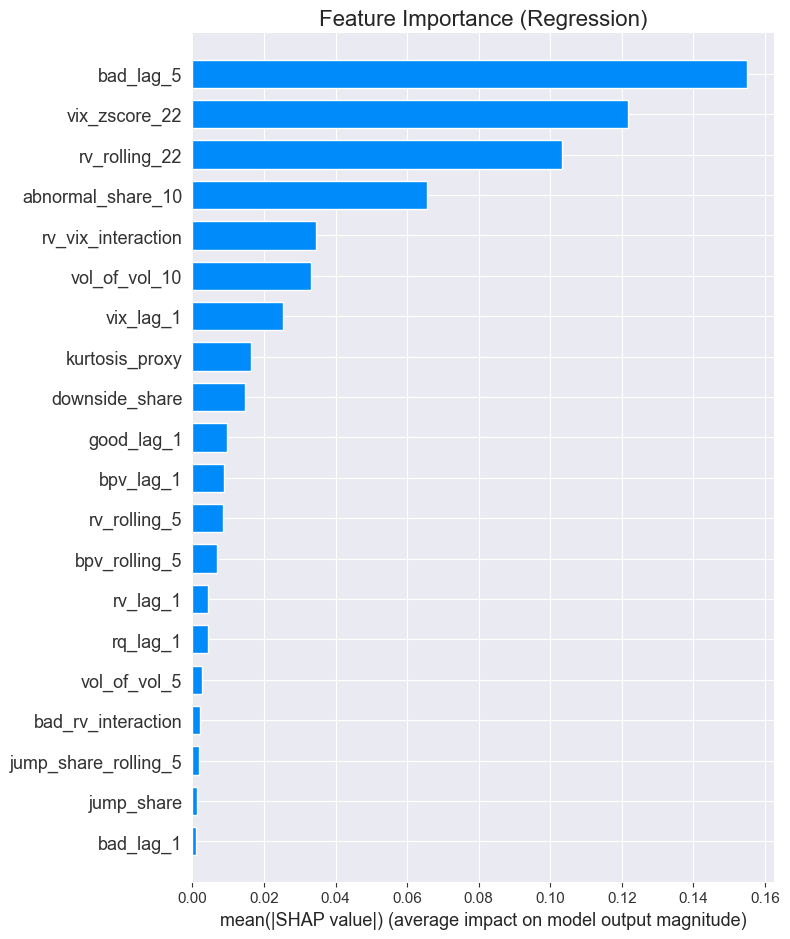

  Plotting Regression SHAP Summary...


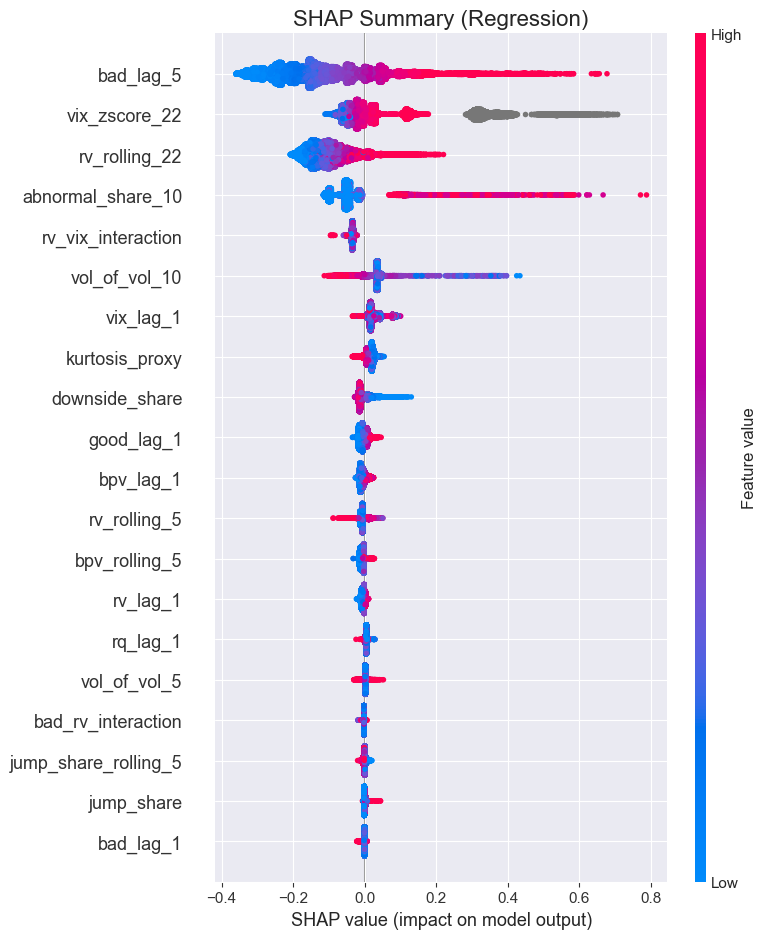


  Calculating SHAP for XGBClassifier (Final Fold)...
  Plotting Classification Feature Importance...


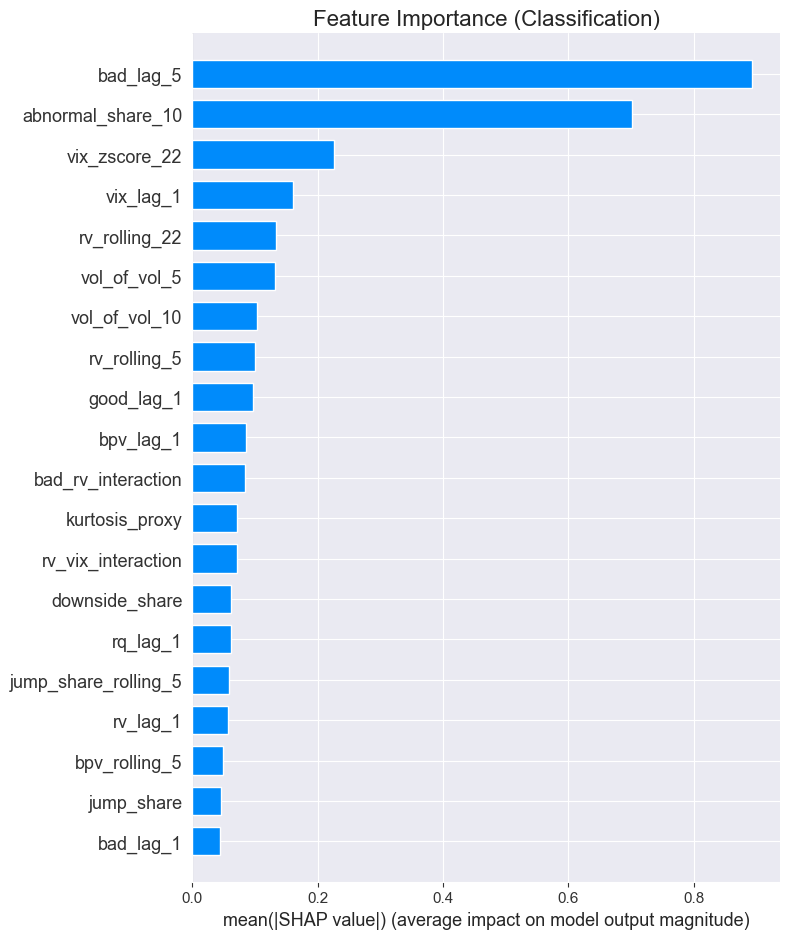

  Plotting Classification SHAP Summary...


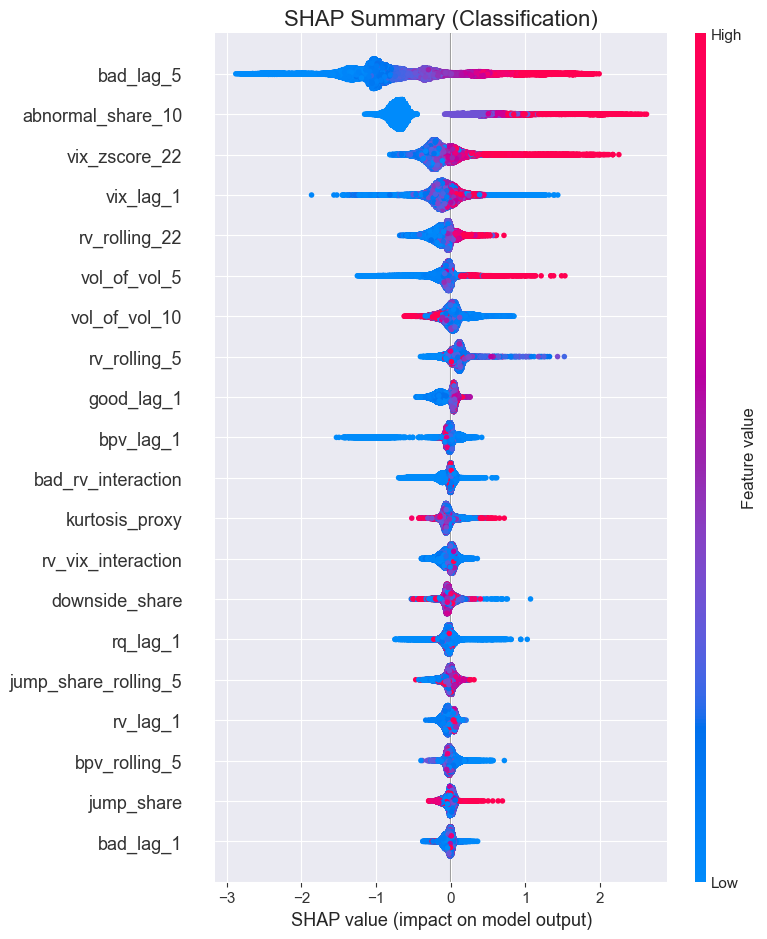

In [78]:
print("\n--- Starting Task 4.3: Model Interpretation (SHAP) ---")
print("  Calculating SHAP for XGBRegressor (Final Fold)...")

final_xgb_reg = xgb_reg_models[-1]
_, test_index_reg = list(tscv.split(X_advanced_log))[-1]
X_test_reg = X_advanced_log.iloc[test_index_reg]

explainer_reg = shap.TreeExplainer(final_xgb_reg)
shap_values_reg = explainer_reg(X_test_reg)

print("  Plotting Regression Feature Importance...")
plt.title('Feature Importance (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Regression SHAP Summary...")
plt.title('SHAP Summary (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.tight_layout()
plt.show()


print("\n  Calculating SHAP for XGBClassifier (Final Fold)...")

final_xgb_class = xgb_class_models[-1]
X_test_class = last_fold_data['X_test']

explainer_class = shap.TreeExplainer(final_xgb_class)
shap_values_class = explainer_class(X_test_class)

print("  Plotting Classification Feature Importance...")
plt.title('Feature Importance (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Classification SHAP Summary...")
plt.title('SHAP Summary (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, show=False)
plt.tight_layout()
plt.show()